<h1 align="center" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">
<font color="#00B871">
Transformers in JAX &mdash; Part 1: From Characters to Tensors at Snapp
</font>
</h1>

<h3 align="left" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">
<font color="#00B871">
Part 1 &mdash; The Backstory
</font>
</h3>

<p dir="ltr" style="direction: ltr;text-align: justify;line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:medium">
<font size=3>
It is a cold Wednesday night in Tehran and the fourth floor of <b>Snapp</b> is still half lit, the smell of strong tea hanging over rows of monitors. Nika has just joined the machine-learning platform team, the group that quietly owns every text feature inside the application, from the destination search box to the little reply suggestions that support agents tap during a chat. Her manager, Borna, drops a single sentence on her desk that will shape the whole month, namely that the team is going to grow its own small language model in-house instead of renting one over the internet. The reason is not fashion but necessity, because passenger messages cannot leave Snapp's own servers and reliable access to foreign model providers is not something anyone wants to bet a production feature on. Borna is clear that the first milestone is not a giant network but a tiny model that the team understands line by line, so that nobody is ever debugging a black box at two in the morning. He hands Nika a one-megabyte text file and a fresh laptop and tells her to start where every language model secretly starts, which is the humble problem of turning text into numbers. Nika opens a notebook, and this is exactly where you join her.
</font>
</p>

<div style="text-align:center;">
    <img src="images/Snapp_logo.png" style="width:100%;">
</div>

<h3 align="left" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">
<font color="#00B871">
Part 2 &mdash; The Mission Brief
</font>
</h3>

<p dir="ltr" style="direction: ltr;text-align: justify;line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:medium">
<font size=3>
Borna sketches the plan for the next five notebooks on the whiteboard, and it reads like the recipe for a real <b>GPT</b>. First the team will learn to tokenize text and feed it to the model, then it will build self-attention, then multi-head attention and the transformer block, then it will train the full model, and finally it will make the model generate text on demand. Every step will be written in <b>JAX</b>, because its just-in-time compiler lets the same clean code run on a laptop during prototyping and on accelerators later in production without a rewrite. For data the team picks something small, public, and rich in structure, namely the complete works of Shakespeare squeezed into a single file, on the theory that a model which can learn to spell and punctuate Elizabethan dialogue can later learn to finish a passenger's sentence. Nika's job tonight is the foundation, which means understanding how JAX differs from plain NumPy, implementing a numerically stable softmax with her own hands, building a character tokenizer, and producing the batched prediction problems that the model will train on. None of this is glamorous, but Borna insists that teams who skip the foundations spend the rest of the quarter paying for it. This notebook is the first link in a continuous five-part chain where each part builds directly on the one before it, culminating in a fully trained MiniGPT, and the integer tensors Nika produces tonight are the foundation that every later part reuses. By the end of the notebook the raw text will have become clean integer tensors, ready for the attention mechanism that the next notebook builds.
</font>
</p>

<div style="text-align:center;">
    <img src="images/Snapp1.png" style="width:100%;">
</div>

<h3 align="left" style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">
<font color="#00B871">
Part 3 &mdash; The Architecture We Are Heading Toward
</font>
</h3>

<p style="line-height:180%; font-size:medium;">
Before touching any code it helps to see the destination. The diagram below is the original <b>Transformer</b> from <i>Attention Is All You Need</i> (Vaswani et al., 2017). The model we build across these five parts keeps only the right-hand <b>decoder</b> column with masked self-attention, and the foundations laid in this very notebook &mdash; a stable softmax, a tokenizer, and batched prediction pairs &mdash; are what feed straight into that column in the parts that follow.
</p>
<div style="text-align:center;">
    <img src="images/transformer_architecture.png" width="430">
    <p style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:small;color:#666;margin-top:6px;"><i>The original Transformer (Vaswani et al., 2017). GPT uses only the right-hand decoder column with masked self-attention; that is the part we rebuild across this lab.</i></p>
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">Learning note &mdash; What exactly is a GPT language model?</h4>
<p style="line-height:180%; font-size:medium;">
A <b>language model</b> assigns probabilities to sequences of tokens, and a <b>GPT</b> is a particular kind that is trained on one objective only, namely predicting the next token given all previous tokens. GPT stands for <i>Generative Pre-trained Transformer</i>: it is <b>generative</b> because you can sample new text from it, <b>pre-trained</b> because it first learns general patterns from a large corpus, and a <b>Transformer</b> because its internal engine is the attention mechanism introduced in the 2017 paper <i>Attention Is All You Need</i>. Crucially, GPT is a <b>decoder-only</b> Transformer, meaning it keeps only the masked-self-attention column of the original architecture so that each position can look at the past but never at the future. Everything in this lab is built around that single idea.
</p>
<div style="text-align:center;">
    <img src="images/gpt_logo.svg" style="width:30%;">
</div>

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">Learning note &mdash; Why build it in JAX?</h4>
<p style="line-height:180%; font-size:medium;">
<b>JAX</b> is a library from Google that looks almost exactly like NumPy but adds three transformations that turn ordinary Python functions into fast, differentiable, vectorized programs. <code>jax.grad</code> gives you the gradient of a function automatically, which is what makes training possible without hand-derived calculus; <code>jax.jit</code> compiles a function with the XLA compiler so that many operations are fused into one fast kernel; and <code>jax.vmap</code> automatically batches a function written for a single example. JAX arrays are <b>immutable</b> and its functions are meant to be <b>pure</b>, which feels strict at first but is exactly what enables those transformations and makes experiments perfectly reproducible. The same code you write tonight on a CPU will run unchanged on a GPU or TPU later.
</p>
<div style="text-align:center;">
    <img src="images/jax_logo.png" style="width:30%;">
</div>

In [1]:
import os, time, math, pickle, urllib.request
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=4, suppress=True)

print("JAX", jax.__version__, "| Flax", nn.__version__ if hasattr(nn,"__version__") else "", "| devices:", jax.devices())

JAX 0.7.2 | Flax  | devices: [CpuDevice(id=0)]


<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">1. JAX in a nutshell: grad, jit, and vmap</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Before any transformer, let us prove the three transformations actually do what the learning note promised. We differentiate a function, time the speed-up from compilation, and batch a function that was written for a single vector.
</p>
</p>

grad of x^3 at x=2: 12.0  (exact 3*2^2 = 12)


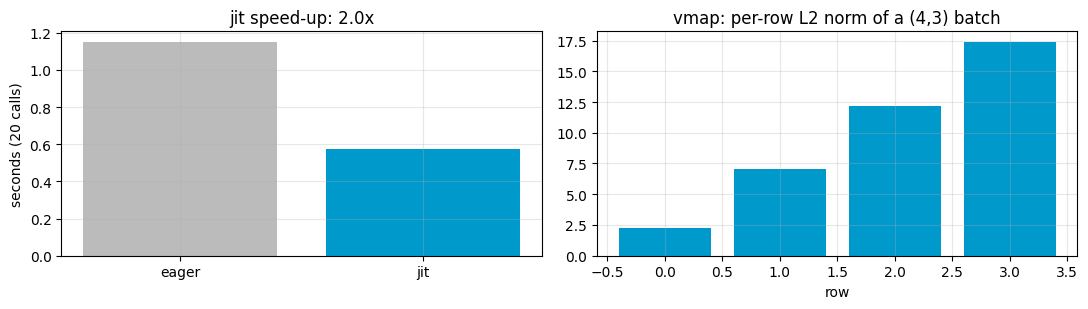

In [2]:
# grad: derivative of f(x)=x^3 is 3x^2, computed for us.
f = lambda x: x ** 3
print("grad of x^3 at x=2:", float(jax.grad(f)(2.0)), " (exact 3*2^2 = 12)")

# jit: compile a heavier function and time it.
def heavy(x):
    for _ in range(60):
        x = jnp.tanh(x) + 0.5 * x
    return jnp.sum(x)
jit_heavy = jax.jit(heavy)
v = jnp.ones(120_000)
jit_heavy(v).block_until_ready()
t0 = time.time(); [heavy(v).block_until_ready() for _ in range(20)]; t_eager = time.time() - t0
t0 = time.time(); [jit_heavy(v).block_until_ready() for _ in range(20)]; t_jit = time.time() - t0

# vmap: a function for one vector, applied to a batch.
batched_norm = jax.vmap(lambda a: jnp.sqrt(jnp.sum(a ** 2)))
norms = batched_norm(jnp.arange(12.0).reshape(4, 3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].bar(["eager", "jit"], [t_eager, t_jit], color=["#bbb", "#0099cc"])
ax[0].set_title(f"jit speed-up: {t_eager / t_jit:.1f}x"); ax[0].set_ylabel("seconds (20 calls)")
ax[1].bar(range(4), np.array(norms), color="#0099cc")
ax[1].set_title("vmap: per-row L2 norm of a (4,3) batch"); ax[1].set_xlabel("row")
plt.tight_layout(); plt.show()

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">Learning note &mdash; Numerically stable softmax</h4>
<p style="line-height:180%; font-size:medium;">
The <b>softmax</b> function turns a vector of real-valued scores into a probability distribution, and it is the operation that lets attention decide how much focus to place on each token. The plain definition is softmax(z)<sub>i</sub> = e<sup>z<sub>i</sub></sup> / &Sigma;<sub>j</sub> e<sup>z<sub>j</sub></sup>, but exponentiating large scores overflows to infinity. The standard fix is to subtract the maximum score first, which does not change the result mathematically because the constant cancels in the ratio, yet keeps every exponential safely below one. You will implement this stable version, since the entire attention mechanism depends on it.
</p>
<div style="text-align:center;">
    <img src="images/softmax.png" width="360">
    <p style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;font-size:small;color:#666;margin-top:6px;"><i>Softmax maps a vector of scores to a probability distribution that sums to one.</i></p>
</div>

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">2. Implement a numerically stable softmax</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Complete the function below. Subtract the per-axis maximum with <code>keepdims=True</code>, exponentiate, and divide by the per-axis sum (again with <code>keepdims=True</code>) so the same code works for both a single vector and a batch of vectors. Do not call <code>jax.nn.softmax</code>, because the judge compares your implementation against it.
</p>
</p>

In [3]:
def stable_softmax(z, axis=-1):
    # TODO: subtract jnp.max(z, axis=axis, keepdims=True) from z for numerical stability,
    #       exponentiate with jnp.exp, then divide by jnp.sum(..., axis=axis, keepdims=True).
    max_z = jnp.max(z, axis=axis, keepdims=True)
    shifted_z = z - max_z
    ez = jnp.exp(shifted_z)
    sum_ez = jnp.sum(ez, axis=axis, keepdims=True)
    return ez / sum_ez

OK: stable_softmax matches jax.nn.softmax and survives huge inputs


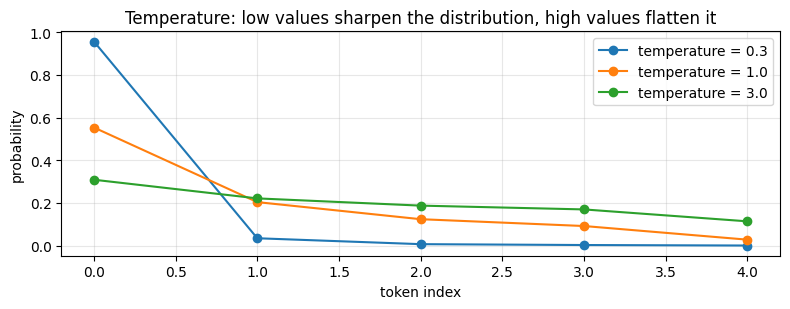

In [4]:
# Self-check + a picture of how temperature reshapes the distribution.
_z = jnp.array([[2.0, 1.0, 0.1], [1000.0, 1001.0, 1002.0]])  # the second row overflows naively
assert jnp.allclose(stable_softmax(_z), jax.nn.softmax(_z, axis=-1), atol=1e-6)
assert jnp.all(jnp.isfinite(stable_softmax(_z)))
print("OK: stable_softmax matches jax.nn.softmax and survives huge inputs")

scores = jnp.array([2.0, 1.0, 0.5, 0.2, -1.0])
fig, ax = plt.subplots(figsize=(8, 3.2))
for T in [0.3, 1.0, 3.0]:
    ax.plot(np.array(stable_softmax(scores / T)), "-o", label=f"temperature = {T}")
ax.set_title("Temperature: low values sharpen the distribution, high values flatten it")
ax.set_xlabel("token index"); ax.set_ylabel("probability"); ax.legend()
plt.tight_layout(); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">3. Loading the Tiny Shakespeare corpus</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
The file <code>tiny_shakespeare.txt</code> holds about one million characters of Shakespeare. We load it once and plot two basic descriptive charts: how often each character appears, and how long the lines are. These are the kinds of plots any engineer runs before trusting a dataset.
</p>
</p>
<div style="text-align:center;">
    <img src="images/Snapp3.png" style="width:100%;">
</div>

Corpus length: 1,115,394 characters
'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst'


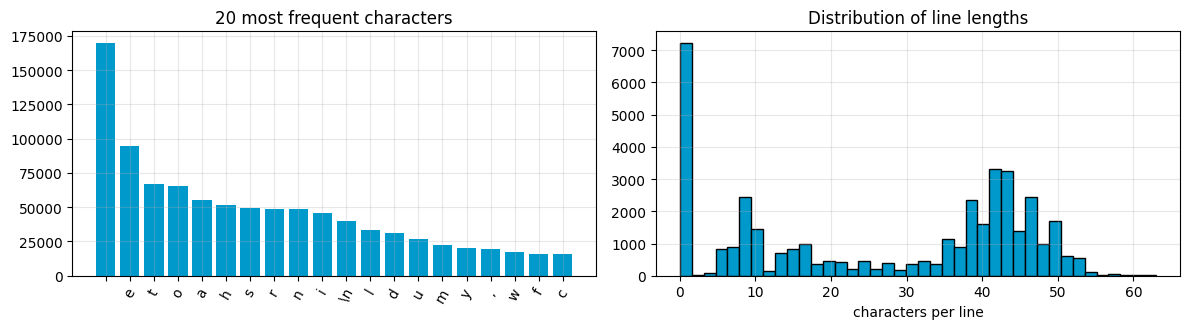

In [5]:
def load_tiny_shakespeare():
    for path in ("data/tiny_shakespeare.txt", "tiny_shakespeare.txt", "../data/tiny_shakespeare.txt"):
        if os.path.exists(path):
            return open(path, encoding="utf-8").read()
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(url, "data/tiny_shakespeare.txt")
    return open("data/tiny_shakespeare.txt", encoding="utf-8").read()

text = load_tiny_shakespeare()
print(f"Corpus length: {len(text):,} characters")
print(repr(text[:180]))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
from collections import Counter
counts = Counter(text)
common = counts.most_common(20)
ax[0].bar([repr(c)[1:-1] for c, _ in common], [n for _, n in common], color="#0099cc")
ax[0].set_title("20 most frequent characters"); ax[0].tick_params(axis="x", rotation=60)
line_lengths = [len(line) for line in text.split("\n")]
ax[1].hist(line_lengths, bins=40, color="#0099cc", edgecolor="black")
ax[1].set_title("Distribution of line lengths"); ax[1].set_xlabel("characters per line")
plt.tight_layout(); plt.show()

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">Learning note &mdash; Tokenization: characters versus sub-words</h4>
<p style="line-height:180%; font-size:medium;">
A neural network only consumes numbers, so the first stage of every language model is <b>tokenization</b>: splitting text into a fixed vocabulary of units and mapping each unit to an integer id. Production GPT models use <b>sub-word</b> tokens produced by Byte-Pair Encoding, so a rare word like <i>tokenization</i> might split into <code>token</code> and <code>ization</code>, which keeps the vocabulary small while still covering any text. In this lab we use the simplest possible scheme, one token per <b>character</b>, because it needs no extra libraries and makes every later tensor easy to read by eye. The mechanics are identical to a real tokenizer; only the size and meaning of the vocabulary change.
</p>
<div style="text-align:center;">
    <img src="images/Snapp2.png" style="width:100%;">
</div>

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">4. Build the character tokenizer</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Using the global <code>text</code>, build the vocabulary and the encode/decode helpers. The list <code>chars</code> must be the <b>sorted</b> unique characters (sorting makes the ids deterministic, which the judge relies on), <code>vocab_size</code> their count, <code>stoi</code> the map from character to integer id, and <code>itos</code> its inverse. The function <code>encode</code> returns a list of ids for a string, <code>decode</code> turns ids back into a string, and <code>data</code> is the whole corpus encoded as an <code>int32</code> NumPy array. The round-trip <code>decode(encode(s))</code> must return <code>s</code> exactly.
</p>
</p>

In [12]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return ''.join(itos[int(i)] for i in ids)


data = np.array(encode(text), dtype=np.int32)


In [13]:
# Self-check
assert decode(encode("Snapp loves JAX!")) == "Snapp loves JAX!"
assert vocab_size == len(set(text)) and len(stoi) == vocab_size == len(itos)
assert data.dtype == np.int32 and len(data) == len(text)
print("OK: vocab_size =", vocab_size)
print("first 20 chars:", repr(text[:20]))
print("first 20 ids  :", data[:20].tolist())

OK: vocab_size = 65
first 20 chars: 'First Citizen:\nBefor'
first 20 ids  : [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56]


<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">5. Split into training and validation sets</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
We keep the first 90% of the corpus for training and the last 10% for validation, so we can detect overfitting later. The chart shows the two contiguous regions.
</p>
</p>

train: 1,003,854 tokens | val: 111,540 tokens


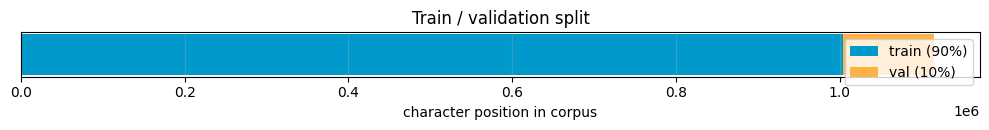

In [14]:
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f"train: {len(train_data):,} tokens | val: {len(val_data):,} tokens")
fig, ax = plt.subplots(figsize=(10, 1.4))
ax.barh([0], [len(train_data)], color="#0099cc", label="train (90%)")
ax.barh([0], [len(val_data)], left=[len(train_data)], color="#ffb347", label="val (10%)")
ax.set_yticks([]); ax.set_xlabel("character position in corpus"); ax.legend(loc="upper right")
ax.set_title("Train / validation split"); plt.tight_layout(); plt.show()

<h4 style="font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">Learning note &mdash; The next-token prediction objective</h4>
<p style="line-height:180%; font-size:medium;">
A GPT is trained on one deceptively simple game: given the characters so far, predict the next one. We cut the corpus into chunks of length <code>block_size</code> (the context window). For each chunk <code>x</code> the target <code>y</code> is the same chunk shifted one position to the left, so a single chunk yields <code>block_size</code> prediction problems at once, one at every position. Position t must predict <code>y[t]</code> using only <code>x[:t+1]</code>, never the future, which is precisely why the attention you build next must be causal.
</p>

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">6. Mini-batches of (context, target) pairs</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
Implement <code>get_batch</code>. Pick the right split, draw <code>batch_size</code> random start positions with <code>jax.random.randint(key, (batch_size,), 0, len(source) - block_size - 1)</code>, convert them with <code>np.asarray</code>, stack <code>source[i:i+block_size]</code> into <code>x</code> and <code>source[i+1:i+1+block_size]</code> into <code>y</code>, and return them as JAX arrays of shape <code>(batch_size, block_size)</code>.
</p>
</p>
<div style="text-align:center;">
    <img src="images/Snapp4.png" style="width:100%;">
</div>

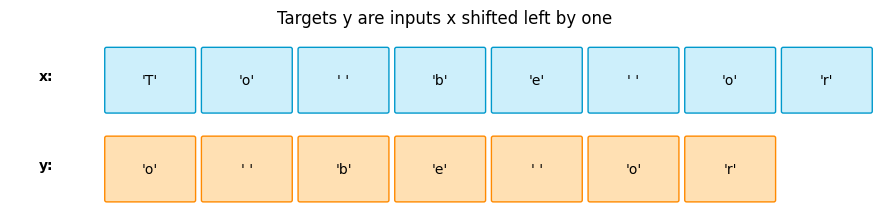

In [15]:
# A picture of the shift relationship before you implement it.
from matplotlib.patches import FancyBboxPatch
sample = "To be or"
fig, ax = plt.subplots(figsize=(9, 2.3))
for i, ch in enumerate(sample):
    ax.add_patch(FancyBboxPatch((i, 1.1), 0.9, 0.7, boxstyle="round,pad=0.02", fc="#cdeffb", ec="#0099cc"))
    ax.text(i + 0.45, 1.45, repr(ch), ha="center", va="center")
    if i < len(sample) - 1:
        ax.add_patch(FancyBboxPatch((i, 0.1), 0.9, 0.7, boxstyle="round,pad=0.02", fc="#ffe0b3", ec="#ff8a00"))
        ax.text(i + 0.45, 0.45, repr(sample[i + 1]), ha="center", va="center")
ax.text(-0.7, 1.45, "x:", weight="bold"); ax.text(-0.7, 0.45, "y:", weight="bold")
ax.set_xlim(-1, len(sample)); ax.set_ylim(0, 2); ax.axis("off")
ax.set_title("Targets y are inputs x shifted left by one")
plt.tight_layout(); plt.show()

In [16]:
def get_batch(key, split, batch_size, block_size):
    # return x, y each of shape (batch_size, block_size); y is x shifted left by one.

    source = train_data if split == "train" else val_data

    ix = jax.random.randint(
        key,
        (batch_size,),
        0,
        len(source) - block_size - 1
    )
    ix = np.asarray(ix)

    x = np.stack([source[i:i+block_size] for i in ix])
    y = np.stack([source[i+1:i+1+block_size] for i in ix])

    return jnp.asarray(x), jnp.asarray(y)

context x[0]: 'the ice,'
target  y[0]: 'he ice,\n'
  given 't'          -> predict 'h'
  given 'th'         -> predict 'e'
  given 'the'        -> predict ' '
  given 'the '       -> predict 'i'
  given 'the i'      -> predict 'c'
  given 'the ic'     -> predict 'e'
  given 'the ice'    -> predict ','
  given 'the ice,'   -> predict '\n'


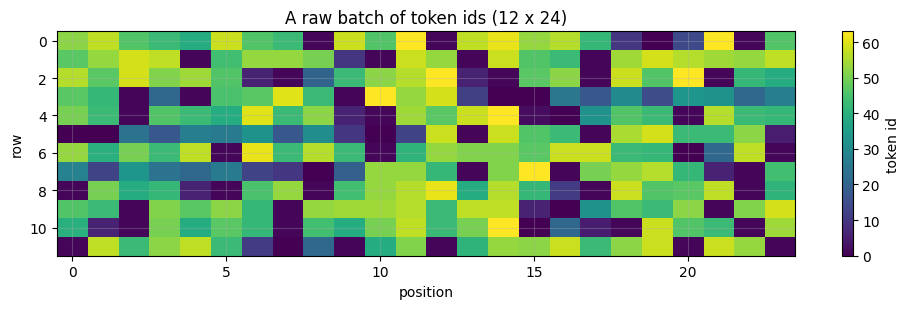

In [17]:
# Self-check + a heatmap of one real batch.
xb, yb = get_batch(jax.random.PRNGKey(1), "train", 4, 8)
assert xb.shape == yb.shape == (4, 8)
print("context x[0]:", repr(decode(xb[0])))
print("target  y[0]:", repr(decode(yb[0])))
for t in range(8):
    print(f"  given {repr(decode(xb[0][:t+1])):<12} -> predict {repr(decode([yb[0][t]]))}")

xb_show, _ = get_batch(jax.random.PRNGKey(7), "train", 12, 24)
fig, ax = plt.subplots(figsize=(10, 3.2))
im = ax.imshow(np.array(xb_show), aspect="auto", cmap="viridis")
ax.set_title("A raw batch of token ids (12 x 24)"); ax.set_xlabel("position"); ax.set_ylabel("row")
fig.colorbar(im, ax=ax, label="token id"); plt.tight_layout(); plt.show()

<h3 style="line-height:200%;font-family:'Vazirmatn',Tahoma,'Segoe UI',system-ui,Arial,sans-serif;color:#00B871">7. Bonus analysis: what must the model actually learn?</h3>
<p style="line-height:180%; font-size:medium;">
<p style="line-height:180%; font-size:medium;">
A language model has to capture which character tends to follow which. We can preview that structure directly from the data with a <b>bigram transition matrix</b>: entry (i, j) is how often character j follows character i. The bright diagonal-ish structure is exactly the regularity attention will learn to exploit in the next notebooks.
</p>
</p>
<div style="text-align:center;">
    <img src="images/Snapp5.png" style="width:100%;">
</div>

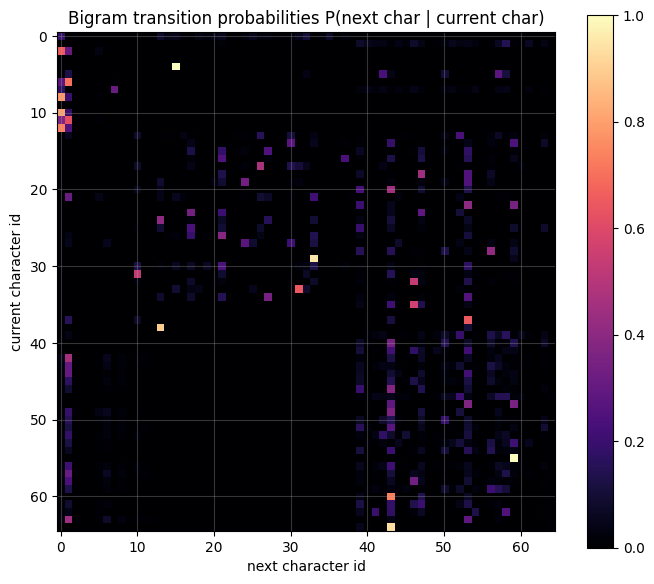

after a space, most likely next chars: [('t', 0.146), ('a', 0.08), ('h', 0.079), ('s', 0.066), ('w', 0.065), ('m', 0.056), ('b', 0.048), ('o', 0.045)]


In [18]:
bigram = np.zeros((vocab_size, vocab_size))
ids = data[:200000]
np.add.at(bigram, (ids[:-1], ids[1:]), 1)
bigram_norm = bigram / (bigram.sum(axis=1, keepdims=True) + 1e-9)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(bigram_norm, cmap="magma")
ax.set_title("Bigram transition probabilities P(next char | current char)")
ax.set_xlabel("next character id"); ax.set_ylabel("current character id")
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()
# a concrete row: what usually follows a space?
sp = stoi[" "]
top = np.argsort(-bigram_norm[sp])[:8]
print("after a space, most likely next chars:", [(itos[int(t)], round(float(bigram_norm[sp, t]), 3)) for t in top])